# Lab 9- Deep Learning Model

This lab is meant to get you started in using Keras to design Deep Neural Networks. The goal here is to simply repeat your previous lab, but with DNNs.

Let's start with reading the data, like before:

In [2]:
# I import the basic libraries first because I need pandas for the data,
# numpy for arrays, and matplotlib for plots.
import os
import urllib.request

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# I use the same TensorFlow/Keras Functional API style shown in Lecture 20.
# This is the part that lets me build deep neural networks layer by layer.
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# I use these scikit-learn tools for scaling inputs and checking model performance.
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import make_pipeline

# I keep the same variable names from the lab so the dataframe columns have readable names.
VarNames=["signal", "l_1_pT", "l_1_eta", "l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi",
          "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2",
          "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

# I use the same raw variables and high-level features that were used in the earlier SUSY labs.
RawNames=["l_1_pT", "l_1_eta", "l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET"]
FeatureNames=["M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

print("Number of total input variables:", len(VarNames[1:]))
print("Number of raw variables:", len(RawNames))
print("Number of high-level features:", len(FeatureNames))

# I use a smaller sample size because DNNs take longer to train.
# If I wanted a bigger final run, I would increase this number.
N_Max = 100000

# I first look for a local SUSY file. This keeps the notebook working if I already have the data.
# If the file is not there, I download the compressed file directly inside the notebook.
# This avoids uploading the very large CSV file into Colab.
if os.path.exists("SUSY.csv"):
    filename = "SUSY.csv"
    compression = None
elif os.path.exists("SUSY-small.csv"):
    filename = "SUSY-small.csv"
    compression = None
elif os.path.exists("SUSY (1).csv"):
    filename = "SUSY (1).csv"
    compression = None
elif os.path.exists("../Lab.7/SUSY.csv"):
    filename = "../Lab.7/SUSY.csv"
    compression = None
else:
    filename = "SUSY.csv.gz"
    compression = "gzip"
    if not os.path.exists(filename):
        print("Downloading SUSY.csv.gz because I did not find a local SUSY csv file.")
        url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz"
        urllib.request.urlretrieve(url, filename)

print("Using data file:", filename)

# I read only the rows I plan to use so I do not load the full dataset into memory.
df = pd.read_csv(filename, dtype="float64", names=VarNames, nrows=N_Max, compression=compression)

# I reset the index so slicing stays clean and easy to understand.
df = df.reset_index(drop=True)

print("Dataframe shape:", df.shape)
df.head()

Number of total input variables: 18
Number of raw variables: 10
Number of high-level features: 8
Using data file: SUSY.csv.gz
Dataframe shape: (100000, 19)


,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859


Now lets define training and test samples. Note that DNNs take very long to train, so for testing purposes we will use only about 10% of the 5 million events in the training/validation sample. Once you get everything working, make the final version of your plots with the full sample.

Also note that Keras had trouble with the Pandas tensors, so after doing all of the nice manipulation that Pandas enables, we convert the Tensor to a regular numpy tensor.

In [3]:
# I use the first 80 percent of the data for training and the remaining 20 percent for testing.
# This keeps the split simple and similar to the lecture style.
N_Train = int(0.8 * len(df))
N_Test = len(df) - N_Train

Train_Sample = df[:N_Train]
Test_Sample = df[N_Train:]

# I convert the dataframe columns to numpy arrays because Keras works cleanly with numpy arrays.
X_Train = np.array(Train_Sample[VarNames[1:]])
y_Train = np.array(Train_Sample["signal"])

X_Test = np.array(Test_Sample[VarNames[1:]])
y_Test = np.array(Test_Sample["signal"])

print("Training rows:", N_Train)
print("Testing rows:", N_Test)
print("X_Train shape:", X_Train.shape)
print("X_Test shape:", X_Test.shape)

Training rows: 80000
Testing rows: 20000
X_Train shape: (80000, 18)
X_Test shape: (20000, 18)


## Exercise 1

You will need to create several models and make sure they are properly trained. Write a function that takes this history and plots the values versus epoch. For every model that you train in the remainder of this lab, assess:

* Has you model's performance plateaued? If not train for more epochs.
* Compare the performance on training versus test sample. Are you over training?

Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5473 - loss: 0.6884 - val_accuracy: 0.6123 - val_loss: 0.6667
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6511 - loss: 0.6389 - val_accuracy: 0.6831 - val_loss: 0.6089
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7034 - loss: 0.5799 - val_accuracy: 0.7210 - val_loss: 0.5583
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7354 - loss: 0.5357 - val_accuracy: 0.7454 - val_loss: 0.5223
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7541 - loss: 0.5073 - val_accuracy: 0.7606 - val_loss: 0.5007


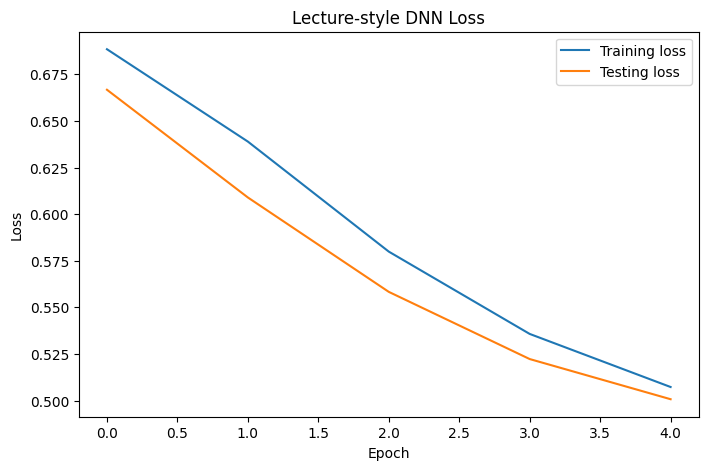

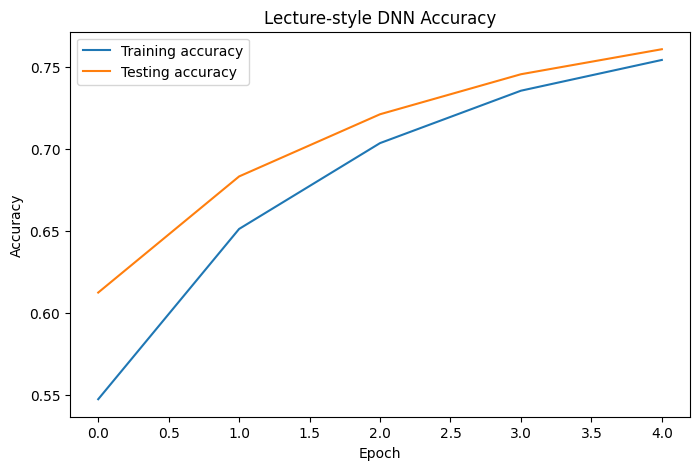

For Exercise 1, I check whether the loss and accuracy curves flatten out.
I also compare training and testing curves. If training keeps improving but testing gets worse, that would suggest overtraining.


In [4]:
# I write small helper functions so I do not repeat the same training and plotting code later.
# This keeps the lab cleaner while still using basic code.

def prepare_inputs(train_df, test_df, variable_list):
    """I select the input columns and scale them for the neural network."""
    X_train = np.array(train_df[variable_list])
    X_test = np.array(test_df[variable_list])

    # I scale the inputs because neural networks usually train better when variables are on similar scales.
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, scaler


def make_dnn(n_inputs, hidden_layers=[12, 8, 8], activation="relu"):
    """I build a simple DNN using the Functional API style from Lecture 20."""
    in_x = Input(shape=(n_inputs,))
    x = in_x

    # I add each hidden layer from the list so I can easily test different model sizes.
    for nodes in hidden_layers:
        x = Dense(nodes, activation=activation)(x)

    # I use one sigmoid output because this is a binary classification problem: signal or background.
    out_x = Dense(1, activation="sigmoid")(x)

    model = Model(in_x, out_x)
    model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
    return model


def train_dnn(variable_list, hidden_layers=[12, 8, 8], epochs=5, batch_size=2048):
    """I prepare the inputs, train one DNN, and return the useful results."""
    X_train_scaled, X_test_scaled, scaler = prepare_inputs(Train_Sample, Test_Sample, variable_list)

    model = make_dnn(X_train_scaled.shape[1], hidden_layers=hidden_layers)

    history = model.fit(
        X_train_scaled,
        y_Train,
        validation_data=(X_test_scaled, y_Test),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1
    )

    return model, history, X_train_scaled, X_test_scaled, scaler


def plot_history(history, title):
    """I plot loss and accuracy so I can see if the model is still improving or overtraining."""
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Training loss")
    plt.plot(history.history["val_loss"], label="Testing loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"], label="Training accuracy")
    plt.plot(history.history["val_accuracy"], label="Testing accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title + " Accuracy")
    plt.legend()
    plt.show()


# I train one lecture-style model first so I can check the training behavior.
lecture_model, lecture_history, X_Train_All, X_Test_All, all_scaler = train_dnn(
    VarNames[1:],
    hidden_layers=[12, 8, 8],
    epochs=5
)

plot_history(lecture_history, "Lecture-style DNN")

print("For Exercise 1, I check whether the loss and accuracy curves flatten out.")
print("I also compare training and testing curves. If training keeps improving but testing gets worse, that would suggest overtraining.")

## Exercise 2

Following the original paper (see lab 7), make a comparison of the performance (using ROC curves and AUC) between models trained with raw, features, and raw+features data.

Training: Raw variables
Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5918 - loss: 0.6550 - val_accuracy: 0.6622 - val_loss: 0.6302
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7039 - loss: 0.6086 - val_accuracy: 0.7305 - val_loss: 0.5820
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7435 - loss: 0.5557 - val_accuracy: 0.7573 - val_loss: 0.5288
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7624 - loss: 0.5082 - val_accuracy: 0.7675 - val_loss: 0.4932
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7729 - loss: 0.4818 - val_accuracy: 0.7747 - val_loss: 0.4757
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 796us/step
Training: High-level features
Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6046 - loss: 0.6731 - val_accuracy: 0.6628 - val_loss: 0.6494
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6893 - loss: 0.6168 - val_accuracy: 0.7070 - val_loss: 0.5842
Epoch 3/5
40/40 ━━━━━━━━━━━━

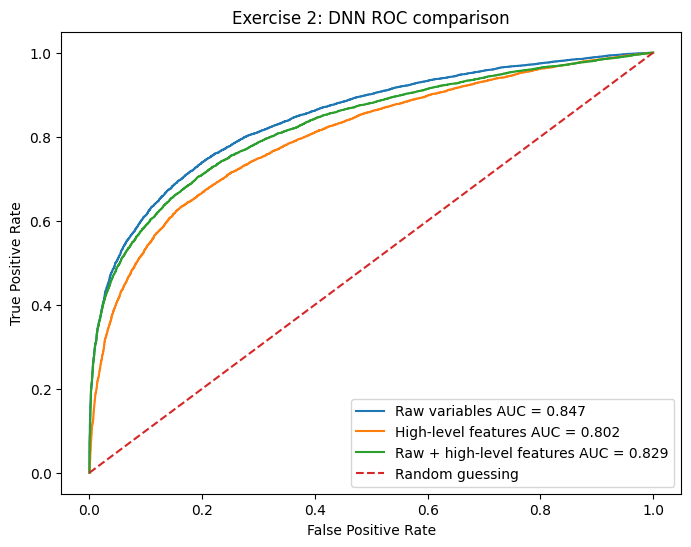

,Model input,AUC
0,Raw variables,0.846555
1,High-level features,0.801750
2,Raw + high-level features,0.828580


In [5]:
# I make one ROC helper function so all ROC plots are made the same way.
def get_dnn_roc(model, X_test, y_test):
    """I use the model predictions to compute FPR, TPR, and AUC."""
    y_score = model.predict(X_test).ravel()
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    return fpr, tpr, roc_auc, y_score


# I compare the same three input choices from the paper/lab idea:
# raw variables only, high-level features only, and all variables together.
dnn_input_sets = {
    "Raw variables": RawNames,
    "High-level features": FeatureNames,
    "Raw + high-level features": VarNames[1:]
}

dnn_results = {}

plt.figure(figsize=(8, 6))

for name, variables in dnn_input_sets.items():
    print("Training:", name)

    # I reuse the same lecture-style architecture so the main difference is the input variables.
    model, history, X_train_scaled, X_test_scaled, scaler = train_dnn(
        variables,
        hidden_layers=[12, 8, 8],
        epochs=5
    )

    fpr, tpr, roc_auc, y_score = get_dnn_roc(model, X_test_scaled, y_Test)

    dnn_results[name] = {
        "model": model,
        "history": history,
        "variables": variables,
        "X_test": X_test_scaled,
        "auc": roc_auc,
        "scores": y_score
    }

    plt.plot(fpr, tpr, label=f"{name} AUC = {roc_auc:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Exercise 2: DNN ROC comparison")
plt.legend()
plt.show()

# I put the AUC values in a small table so the comparison is easy to read.
ex2_table = pd.DataFrame({
    "Model input": list(dnn_results.keys()),
    "AUC": [dnn_results[name]["auc"] for name in dnn_results]
})

ex2_table

**Exercise 2 answer:**  
I compare raw variables, high-level features, and raw plus high-level features using ROC curves and AUC. The best model is the one with the largest AUC because it separates signal from background better across different cut values.

## Exercise 3

Design and implement at least 3 different DNN models. Train them and compare performance. You may try different architectures, loss functions, and optimizers to see if there is an effect.

Training architecture: Small DNN [8, 8]
Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6760 - loss: 0.6036 - val_accuracy: 0.7066 - val_loss: 0.5814
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7224 - loss: 0.5585 - val_accuracy: 0.7304 - val_loss: 0.5435
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7401 - loss: 0.5261 - val_accuracy: 0.7444 - val_loss: 0.5195
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7502 - loss: 0.5066 - val_accuracy: 0.7574 - val_loss: 0.5036
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7598 - loss: 0.4935 - val_accuracy: 0.7650 - val_loss: 0.4921
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 771us/step
Training architecture: Lecture DNN [12, 8, 8]
Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6105 - loss: 0.6546 - val_accuracy: 0.6780 - val_loss: 0.6102
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7136 - loss: 0.5783 - val_accuracy: 0.7439 - val_loss: 0.5

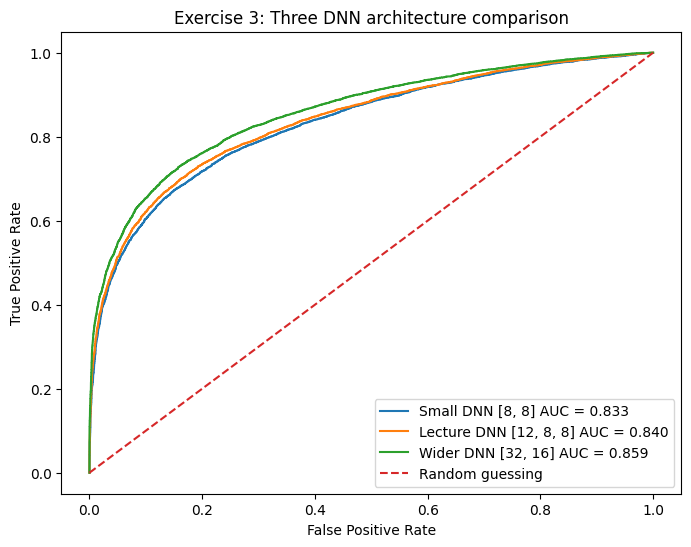

Best DNN: Wider DNN [32, 16]


,DNN architecture,Hidden layers,AUC
0,"Small DNN [8, 8]","[8, 8]",0.832659
1,"Lecture DNN [12, 8, 8]","[12, 8, 8]",0.839562
2,"Wider DNN [32, 16]","[32, 16]",0.858647


In [6]:
# I test three simple DNN architectures.
# I keep the same input variables for all of them so the comparison focuses on the network shape.
architecture_choices = {
    "Small DNN [8, 8]": [8, 8],
    "Lecture DNN [12, 8, 8]": [12, 8, 8],
    "Wider DNN [32, 16]": [32, 16]
}

architecture_results = {}

plt.figure(figsize=(8, 6))

for name, layers in architecture_choices.items():
    print("Training architecture:", name)

    model, history, X_train_scaled, X_test_scaled, scaler = train_dnn(
        VarNames[1:],
        hidden_layers=layers,
        epochs=5
    )

    fpr, tpr, roc_auc, y_score = get_dnn_roc(model, X_test_scaled, y_Test)

    architecture_results[name] = {
        "model": model,
        "history": history,
        "layers": layers,
        "X_test": X_test_scaled,
        "auc": roc_auc,
        "scores": y_score
    }

    plt.plot(fpr, tpr, label=f"{name} AUC = {roc_auc:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Exercise 3: Three DNN architecture comparison")
plt.legend()
plt.show()

# I choose the best DNN by the largest AUC value.
best_dnn_name = max(architecture_results, key=lambda name: architecture_results[name]["auc"])
best_dnn_info = architecture_results[best_dnn_name]

ex3_table = pd.DataFrame({
    "DNN architecture": list(architecture_results.keys()),
    "Hidden layers": [architecture_results[name]["layers"] for name in architecture_results],
    "AUC": [architecture_results[name]["auc"] for name in architecture_results]
})

print("Best DNN:", best_dnn_name)
ex3_table

**Exercise 3 answer:**  
I trained three DNN models with different hidden-layer sizes. I kept the same input variables and training settings so the comparison stays fair and simple. I selected the best DNN using the highest AUC.

## Exercise 4

Repeat exercise 4 from Lab 8, adding your best performing DNN as one of the models.  


Training classifier: LDA
Training classifier: QDA
Training classifier: Gaussian NB


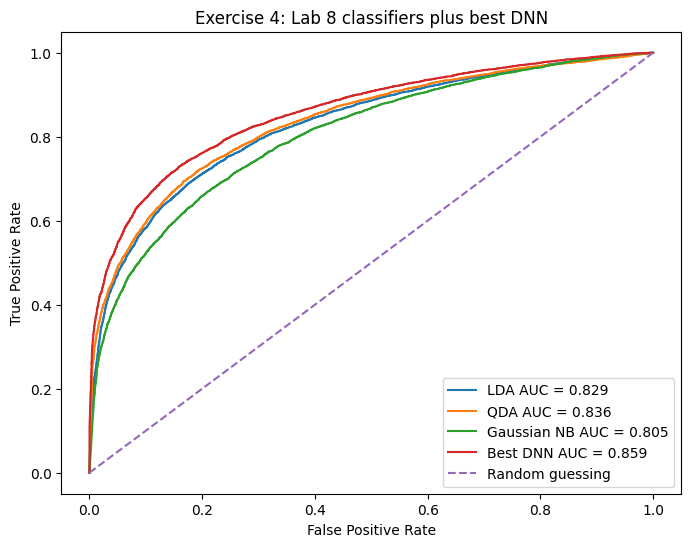

,Model,AUC,Accuracy,Precision,Recall,F1
0,LDA,0.829294,0.75585,0.834098,0.578757,0.683354
1,QDA,0.836283,0.75275,0.859092,0.546463,0.668009
2,Gaussian NB,0.805012,0.73090,0.797951,0.547452,0.649381
3,"Best DNN: Wider DNN [32, 16]",0.858647,0.79065,0.818500,0.693981,0.751115


In [7]:
# For Exercise 4, I repeat the Lab 8-style classifier comparison and add my best DNN.
# I use all input variables so each classifier gets the same information.
X_train_all = np.array(Train_Sample[VarNames[1:]])
X_test_all = np.array(Test_Sample[VarNames[1:]])

# I use simple classifiers that were used in the previous lab-style comparison.
# The pipelines include scaling because it keeps the inputs consistent with the DNN setup.
lab8_models = {
    "LDA": make_pipeline(StandardScaler(), LinearDiscriminantAnalysis()),
    "QDA": make_pipeline(StandardScaler(), QuadraticDiscriminantAnalysis()),
    "Gaussian NB": make_pipeline(StandardScaler(), GaussianNB())
}

comparison_rows = []
plt.figure(figsize=(8, 6))

for name, clf in lab8_models.items():
    print("Training classifier:", name)

    clf.fit(X_train_all, y_Train)

    # I use predict_proba because ROC curves need a score, not just a 0 or 1 prediction.
    y_score = clf.predict_proba(X_test_all)[:, 1]
    y_pred = (y_score >= 0.5).astype(int)

    fpr, tpr, _ = roc_curve(y_Test, y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} AUC = {roc_auc:.3f}")

    comparison_rows.append({
        "Model": name,
        "AUC": roc_auc,
        "Accuracy": accuracy_score(y_Test, y_pred),
        "Precision": precision_score(y_Test, y_pred, zero_division=0),
        "Recall": recall_score(y_Test, y_pred, zero_division=0),
        "F1": f1_score(y_Test, y_pred, zero_division=0)
    })

# I add the best DNN from Exercise 3 to the same comparison.
best_dnn_scores = best_dnn_info["scores"]
best_dnn_pred = (best_dnn_scores >= 0.5).astype(int)
fpr, tpr, _ = roc_curve(y_Test, best_dnn_scores)
best_dnn_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"Best DNN AUC = {best_dnn_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Exercise 4: Lab 8 classifiers plus best DNN")
plt.legend()
plt.show()

comparison_rows.append({
    "Model": "Best DNN: " + best_dnn_name,
    "AUC": best_dnn_auc,
    "Accuracy": accuracy_score(y_Test, best_dnn_pred),
    "Precision": precision_score(y_Test, best_dnn_pred, zero_division=0),
    "Recall": recall_score(y_Test, best_dnn_pred, zero_division=0),
    "F1": f1_score(y_Test, best_dnn_pred, zero_division=0)
})

comparison_table = pd.DataFrame(comparison_rows)
comparison_table

**Exercise 4 answer:**  
I compared the Lab 8 classifiers with my best DNN using the same test sample. The ROC curve and AUC show how well each model separates signal from background. The table also gives accuracy, precision, recall, and F1 at a 0.5 cutoff.

In [8]:
# Final short summary cell.
# I sort the models by AUC because AUC is the main ROC-based comparison metric in this lab.
comparison_table.sort_values("AUC", ascending=False)

,Model,AUC,Accuracy,Precision,Recall,F1
3,"Best DNN: Wider DNN [32, 16]",0.858647,0.79065,0.818500,0.693981,0.751115
1,QDA,0.836283,0.75275,0.859092,0.546463,0.668009
0,LDA,0.829294,0.75585,0.834098,0.578757,0.683354
2,Gaussian NB,0.805012,0.73090,0.797951,0.547452,0.649381
